# Qualification Simulation

A cup (Cup of the Week) has three stages:
1. **Qualification** — 64 players selected from the full field of 128
2. **Race** — 39 elimination rounds determine finish positions 1–64
3. **Scoring** — finish positions mapped to points

This notebook focuses on **stage 1: qualification**.
Given 128 registered players, which 64 make it into each cup?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tmonacodel.config import TournamentConfig
from tmonacodel.player import make_player_pool
from tmonacodel.cup import qualify_players

sns.set_theme(style='whitegrid')

config = TournamentConfig(n_players=128, random_seed=42)
players = make_player_pool(config)

print(f"Total players: {config.n_players}")
print(f"Qualifiers per cup: {config.n_qualifiers}")
print(f"Expected qualification rate: {config.n_qualifiers / config.n_players:.1%}")

Total players: 128
Qualifiers per cup: 64
Expected qualification rate: 50.0%


## One qualification draw

`qualify_players` picks 64 distinct player IDs from 0–127 using `rng.choice` without replacement.
Currently there are no skill weights — every player has an equal 50% chance each cup.

In [2]:
rng = np.random.default_rng(42)
qualifier_ids = qualify_players(config.n_players, config.n_qualifiers, rng)

qualified_mask = np.zeros(config.n_players, dtype=bool)
qualified_mask[qualifier_ids] = True

df_single = pd.DataFrame({
    "player_id": np.arange(config.n_players),
    "name": [p.name for p in players],
    "qualified": qualified_mask,
})

print(f"Qualifiers this draw: {qualified_mask.sum()}")
print("\nFirst 10 qualified players:")
df_single[df_single.qualified].head(10)

Qualifiers this draw: 64

First 10 qualified players:


,player_id,name,qualified
5,5,Generic_05,True
6,6,Generic_06,True
7,7,Generic_07,True
8,8,Generic_08,True
10,10,Generic_10,True
14,14,Generic_14,True
15,15,Generic_15,True
17,17,Generic_17,True
18,18,Generic_18,True
21,21,Generic_21,True


## Sanity check: qualification rate over 10,000 cups

With uniform random selection and 64 slots from 128 players, each player qualifies
exactly 50% of the time on average. The histogram below should be tightly centred on 5,000.

Expected rate:  0.500
Mean observed:  0.500
Min observed:   0.486
Max observed:   0.512
Std dev:        0.0055


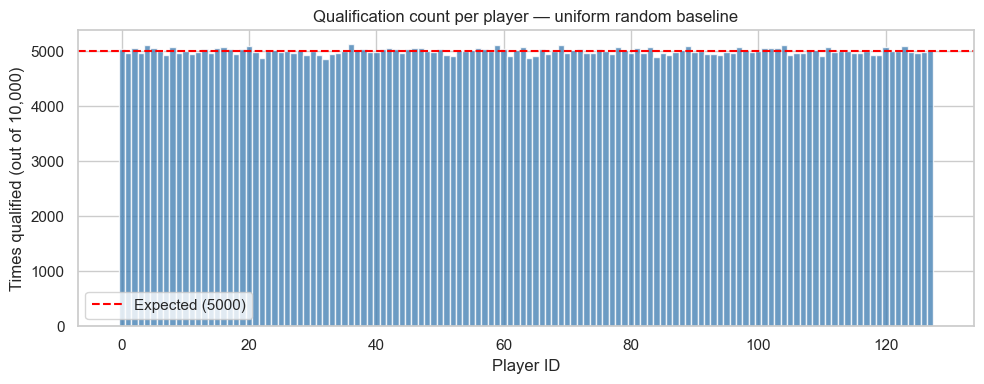

In [3]:
n_trials = 10_000
rng = np.random.default_rng(42)

# Count how many times each player qualifies across all trials
qual_counts = np.zeros(config.n_players, dtype=np.int64)
for _ in range(n_trials):
    ids = qualify_players(config.n_players, config.n_qualifiers, rng)
    qual_counts[ids] += 1

qual_rates = qual_counts / n_trials
expected_rate = config.n_qualifiers / config.n_players

print(f"Expected rate:  {expected_rate:.3f}")
print(f"Mean observed:  {qual_rates.mean():.3f}")
print(f"Min observed:   {qual_rates.min():.3f}")
print(f"Max observed:   {qual_rates.max():.3f}")
print(f"Std dev:        {qual_rates.std():.4f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(np.arange(config.n_players), qual_counts, width=1.0, color='steelblue', alpha=0.8)
ax.axhline(n_trials * expected_rate, color='red', linestyle='--',
           label=f'Expected ({n_trials * expected_rate:.0f})')
ax.set_xlabel("Player ID")
ax.set_ylabel(f"Times qualified (out of {n_trials:,})")
ax.set_title("Qualification count per player — uniform random baseline")
ax.legend()
plt.tight_layout()
plt.show()

## Per-player qualification across 10 cups

Pick three players and track whether they qualify in each of 10 consecutive cups.
Each cell shows **Q** (qualified) or **—** (did not qualify).

In [4]:
# Choose three players to follow
tracked_ids = [0, 42, 99]
tracked_names = [players[i].name for i in tracked_ids]

n_cups = config.n_cups  # 10
rng = np.random.default_rng(42)

# qual_log[player][cup] = True/False
qual_log = {pid: [] for pid in tracked_ids}

for cup in range(n_cups):
    ids = qualify_players(config.n_players, config.n_qualifiers, rng)
    qualifier_set = set(ids.tolist())
    for pid in tracked_ids:
        qual_log[pid].append(pid in qualifier_set)

# Build display table
cup_cols = [f"Cup {i+1}" for i in range(n_cups)]
rows = {}
for pid, name in zip(tracked_ids, tracked_names):
    rows[f"P{pid} ({name})"] = ["Q" if q else "—" for q in qual_log[pid]]

qual_table = pd.DataFrame(rows, index=cup_cols).T
qual_table["Total qualified"] = [
    sum(qual_log[pid]) for pid in tracked_ids
]

print(f"Qualification status over {n_cups} cups (Q = qualified, — = did not qualify)\n")
qual_table

Qualification status over 10 cups (Q = qualified, — = did not qualify)



,Cup 1,Cup 2,Cup 3,Cup 4,Cup 5,Cup 6,Cup 7,Cup 8,Cup 9,Cup 10,Total qualified
P0 (Generic_00),—,—,—,—,—,—,Q,Q,—,Q,3
P42 (Generic_42),Q,Q,Q,—,Q,—,Q,—,—,—,5
P99 (Generic_99),Q,—,Q,—,Q,—,—,—,—,—,3


## What changes next

This flat qualification rate is the **random baseline** for stage 1.

When skill is introduced, `qualify_players` in `cup.py` will accept per-player weights so that
stronger players appear in the qualified field more often. The tracked-player table above will
then show asymmetric qualification rates rather than the ~50% expected here.